# Three splits, three different truths

**Can a model tell a quarry blast from an earthquake using nothing but the
catalogue row? And how much does the answer depend on how I cut the data?**

Elyes Lounissi ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

---

The USGS publishes a row for every seismic event its networks locate. Most rows
are earthquakes. Some are labelled `quarry blast` or `mining explosion`, because
a human analyst looked at the seismogram and decided the ground shook because
somebody set off explosives.

Telling those apart from the waveform is a solved problem in seismology, and the
published classifiers are good — the ones I read report accuracy in the high
nineties using spectral features that require the actual seismograms.

I want to ask a cheaper question. The catalogue row has no waveform in it. It has
a time, a place, a magnitude, and a handful of numbers describing how well the
location was measured. Is that enough?

It turns out the answer is yes, and that the interesting part is not the score.
It is that I can make the same model report 98% or 86% depending only on how I
arrange the folds, and that the arrangement most people reach for by reflex —
a time-based split — protects against almost nothing here.

**The hypothesis, stated so it can fail:** if the model has learned something
about how explosions differ from earthquakes, its score should hold up when I
force it to predict in places it has never seen. If it has instead memorised
where the quarries are, blocking by location should take it apart.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Walk up to the repo root so `toolkit` imports from anywhere in the tree.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import style, evaluate

style.use()
FIG = pathlib.Path("figures")
RANDOM_SEED = 0

## The catalogue

Every explosion the USGS catalogued in the contiguous United States between 2015
and 2025 at magnitude 1.0 and above, matched against earthquakes drawn from the
same months.

The matching matters. Explosions are a working-hours activity whose yearly count
follows construction demand, and earthquake counts are dominated by a few large
aftershock sequences. If I had sampled earthquakes across the whole decade at
once, a model could score well by learning that 2019 was a quiet quarry year —
a fact about my sampling, not about the events. Drawing an equal number of
earthquakes from each calendar month means that within any month the two classes
are exactly balanced, so the date carries no information about the label.

[`data/fetch/usgs_blasts_vs_quakes.py`](../../data/fetch/usgs_blasts_vs_quakes.py)
rebuilds this from the USGS service. It is public domain data.

In [2]:
events = pd.read_csv(ROOT / "data" / "raw" / "usgs-blasts" / "events.csv")
events["time"] = pd.to_datetime(events["time"], format="ISO8601", utc=True)
events = events.sort_values("time").reset_index(drop=True)

print(f"{len(events):,} events, {events['time'].min():%Y-%m-%d} to {events['time'].max():%Y-%m-%d}")
print(events["type"].value_counts().to_string())
print(f"\nlabel 1 = explosion ({events.label.sum():,}), 0 = earthquake ({(1 - events.label).sum():,})")

26,762 events, 2015-01-01 to 2024-12-31
type
earthquake          13381
quarry blast        11196
mining explosion     2185

label 1 = explosion (13,381), 0 = earthquake (13,381)


### Local solar time, not UTC

A quarry crew works a solar day, so the clock that matters is the one on the
wall at the quarry. I do not need a timezone database for this: longitude gives
solar time directly, at four minutes per degree. It is approximate — it ignores
daylight saving and political time zones — but it is the physically right
quantity, and it costs one line.

In [3]:
local_time = events["time"] + pd.to_timedelta(events["longitude"] / 15.0, unit="h")
events["local_hour"] = local_time.dt.hour + local_time.dt.minute / 60
events["weekday"] = local_time.dt.dayofweek          # Monday = 0
events["is_weekend"] = (events["weekday"] >= 5).astype(int)

# Hour is circular: 23:30 and 00:30 are an hour apart, not 23. Projecting onto a
# circle lets a linear model see that, and costs a tree model nothing.
events["hour_sin"] = np.sin(2 * np.pi * events["local_hour"] / 24)
events["hour_cos"] = np.cos(2 * np.pi * events["local_hour"] / 24)

events[["local_hour", "weekday", "hour_sin", "hour_cos"]].head()

,local_hour,weekday,hour_sin,hour_cos
0,23.116667,2,-0.229200,0.973379
1,16.066667,3,-0.874620,-0.484810
2,16.650000,3,-0.938191,-0.346117
3,2.100000,4,0.522499,0.852640
4,6.033333,4,0.999962,-0.008727


## Where the events are

This is the whole problem in one picture.

The busiest 0.1-degree cell holds 925 explosions (6.9% of all of them).
The top ten cells hold 42.0%.


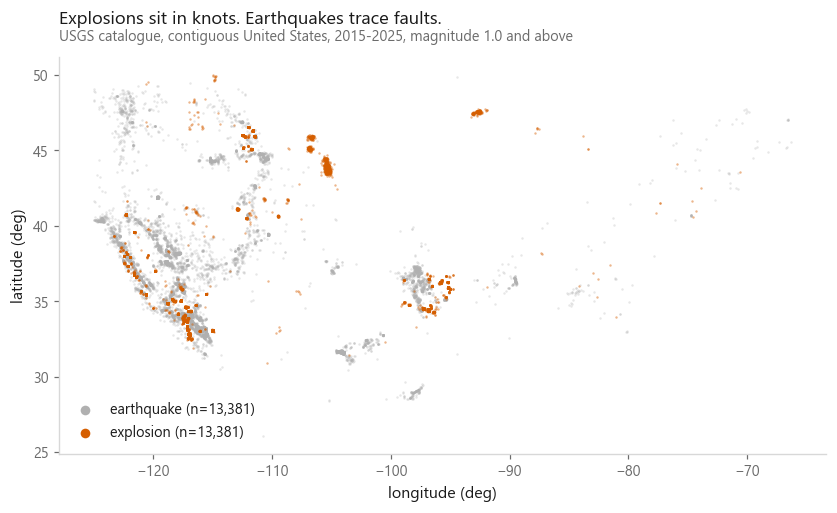

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.2))
quakes, blasts = events[events.label == 0], events[events.label == 1]

ax.scatter(quakes.longitude, quakes.latitude, s=2.5, alpha=0.30,
           c=style.NEUTRAL, linewidths=0, label=f"earthquake (n={len(quakes):,})")
ax.scatter(blasts.longitude, blasts.latitude, s=2.5, alpha=0.45,
           c=style.HIGHLIGHT, linewidths=0, label=f"explosion (n={len(blasts):,})")

# A degree of longitude is shorter than a degree of latitude away from the equator.
ax.set_aspect(1 / np.cos(np.radians(38)))
ax.set_xlabel("longitude (deg)")
ax.set_ylabel("latitude (deg)")
ax.grid(False)
leg = ax.legend(loc="lower left", markerscale=4)
for handle in leg.legend_handles:
    handle.set_alpha(1)

style.title(ax,
            "Explosions sit in knots. Earthquakes trace faults.",
            "USGS catalogue, contiguous United States, 2015-2025, magnitude 1.0 and above")
style.save(fig, FIG / "fig-01-where.png")

top_cell = (blasts.assign(cell=blasts.latitude.round(1).astype(str) + ", " + blasts.longitude.round(1).astype(str))
            .cell.value_counts())
print(f"The busiest 0.1-degree cell holds {top_cell.iloc[0]:,} explosions "
      f"({top_cell.iloc[0] / len(blasts):.1%} of all of them).")
print(f"The top ten cells hold {top_cell.head(10).sum() / len(blasts):.1%}.")

Quarries do not move. A quarry that blasted in 2016 is blasting in 2024 from the
same coordinates, so the orange points pile onto a few hundred pixels. Earthquakes
come from faults, which are lines, not points, and the grey spreads along them.

That asymmetry is what makes this dataset a good place to ask the split question.
A model given latitude and longitude can score extremely well by building a lookup
table of quarry coordinates — and a random split will hand it the answer key,
because the same quarry appears in the training set and the test set.

## Two features I had to throw away

Before any modelling, a look at what the columns actually mean. Two of them
encode the answer.

depth <= 0 : earthquakes 4.0%, explosions 96.3%

reviewed by an analyst:
label          0      1
status                 
automatic  0.088  0.003
reviewed   0.912  0.997


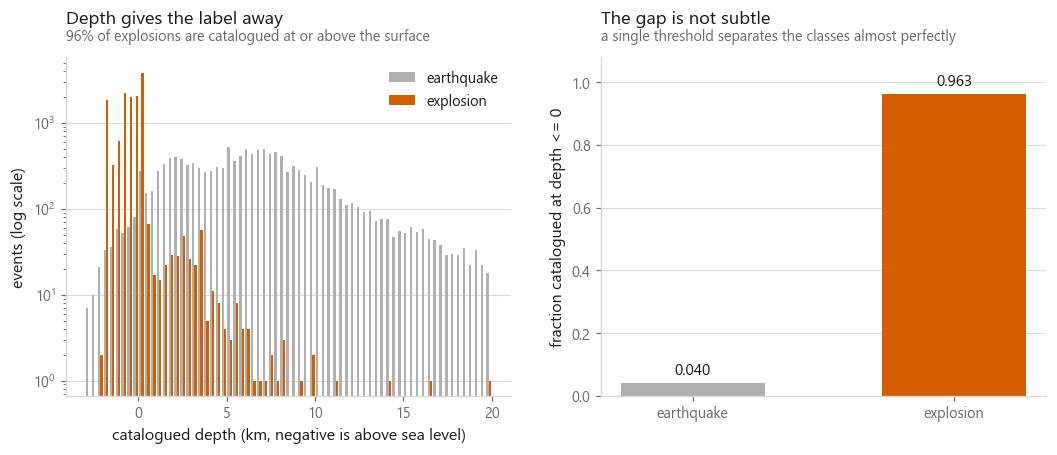

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))

axes[0].hist([quakes.depth, blasts.depth], bins=np.linspace(-3, 20, 70),
             color=[style.NEUTRAL, style.HIGHLIGHT], label=["earthquake", "explosion"])
axes[0].set_yscale("log")
axes[0].set_xlabel("catalogued depth (km, negative is above sea level)")
axes[0].set_ylabel("events (log scale)")
axes[0].legend()
style.title(axes[0], "Depth gives the label away", "96% of explosions are catalogued at or above the surface")

shallow = events.assign(s=events.depth <= 0).groupby("label").s.mean()
reviewed = pd.crosstab(events.status, events.label, normalize="columns")

bars = axes[1].bar(["earthquake", "explosion"], [shallow[0], shallow[1]],
                   color=[style.NEUTRAL, style.HIGHLIGHT], width=0.55)
axes[1].bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
axes[1].set_ylim(0, 1.08)
axes[1].set_ylabel("fraction catalogued at depth <= 0")
style.title(axes[1], "The gap is not subtle", "a single threshold separates the classes almost perfectly")

style.save(fig, FIG / "fig-03-depth.png")

print(f"depth <= 0 : earthquakes {shallow[0]:.1%}, explosions {shallow[1]:.1%}")
print(f"\nreviewed by an analyst:\n{reviewed.round(3).to_string()}")

**Depth goes.** An analyst who has decided an event is a quarry blast fixes its
depth at the surface, because that is where quarry blasts happen. The number is
a consequence of the label, not evidence for it. Feeding it to the model would be
asking the analyst for the answer and then congratulating myself for guessing it.

**Status goes** for the same reason. An event is `reviewed` rather than
`automatic` because a human opened it, and a human opened it in order to apply
the label I am trying to predict.

**Network codes go too**, less obviously. `net`, `locationSource` and `magType`
say which regional network processed the event and which magnitude convention it
used. Those are determined by where the event happened. Keeping them would smuggle
coarse location past a spatial split under a different name, which is exactly the
thing I am trying to measure.

What is left splits into three honest groups.

In [6]:
WHERE = ["latitude", "longitude"]
WHEN = ["hour_sin", "hour_cos", "is_weekend"]
HOW = ["mag", "gap", "dmin", "rms", "nst", "magNst", "horizontalError", "magError"]

FEATURE_SETS = {"all": WHERE + WHEN + HOW, "where": WHERE, "when": WHEN, "how": HOW}

for name, cols in FEATURE_SETS.items():
    print(f"{name:>6}  ({len(cols)})  {', '.join(cols)}")

print("\nmissing values:")
print(events[FEATURE_SETS["all"]].isna().mean().loc[lambda s: s > 0].round(3).to_string())

   all  (13)  latitude, longitude, hour_sin, hour_cos, is_weekend, mag, gap, dmin, rms, nst, magNst, horizontalError, magError
 where  (2)  latitude, longitude
  when  (3)  hour_sin, hour_cos, is_weekend
   how  (8)  mag, gap, dmin, rms, nst, magNst, horizontalError, magError

missing values:
gap                0.001
dmin               0.011
rms                0.000
nst                0.083
magNst             0.019
horizontalError    0.145
magError           0.025


`where` is latitude and longitude. `when` is the clock and the calendar. `how` is
the measurement itself: magnitude, azimuthal gap, distance to the nearest station,
travel-time residual, station counts, and the reported errors.

I should flag that `how` is not as innocent as it looks. Azimuthal gap and
distance-to-nearest-station describe the geometry of the seismic network around
the event, and network density varies by region. Some location information leaks
through that group whatever I do. The experiment below will show how much.

## The clock

Before splitting anything, the signal I expect to be real.

between 08:00 and 18:00 local : explosions 98.7%, earthquakes 40.2%


Monday to Friday              : explosions 94.4%, earthquakes 71.4%


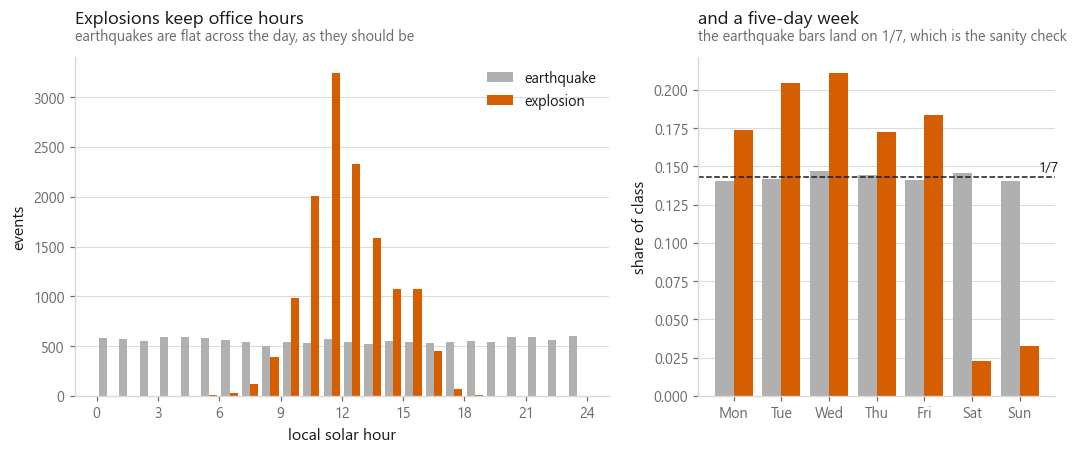

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0), gridspec_kw={"width_ratios": [1.5, 1]})

axes[0].hist([quakes.local_hour, blasts.local_hour], bins=np.arange(0, 25, 1),
             color=[style.NEUTRAL, style.HIGHLIGHT], label=["earthquake", "explosion"])
axes[0].set_xticks(range(0, 25, 3))
axes[0].set_xlabel("local solar hour")
axes[0].set_ylabel("events")
axes[0].legend()
style.title(axes[0], "Explosions keep office hours", "earthquakes are flat across the day, as they should be")

by_day = events.groupby(["weekday", "label"]).size().unstack()
by_day = by_day / by_day.sum()
x = np.arange(7)
axes[1].bar(x - 0.2, by_day[0], width=0.4, color=style.NEUTRAL, label="earthquake")
axes[1].bar(x + 0.2, by_day[1], width=0.4, color=style.HIGHLIGHT, label="explosion")
axes[1].axhline(1 / 7, color=style.INK, lw=1, ls="--")
axes[1].annotate("1/7", xy=(6.4, 1 / 7), xytext=(0, 4), textcoords="offset points",
                 fontsize=9, color=style.INK)
axes[1].set_xticks(x, ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[1].set_ylabel("share of class")
style.title(axes[1], "and a five-day week", "the earthquake bars land on 1/7, which is the sanity check")

style.save(fig, FIG / "fig-02-clock.png")

work = events.local_hour.between(8, 18)
print(f"between 08:00 and 18:00 local : explosions {work[events.label == 1].mean():.1%}, "
      f"earthquakes {work[events.label == 0].mean():.1%}")
print(f"Monday to Friday              : explosions {(events.weekday < 5)[events.label == 1].mean():.1%}, "
      f"earthquakes {(events.weekday < 5)[events.label == 0].mean():.1%}")

The earthquake bars sitting on 1/7 are worth a moment. Nothing in my sampling
forced that. It says the earthquakes I drew behave like a process with no weekly
structure, which is what an unbiased sample of natural seismicity should look
like, and it means the 94% weekday rate on the explosion side is a real
difference rather than an artefact of how I built the file.

This is the signal I would expect to transfer. A quarry I have never seen still
blasts on a Tuesday afternoon.

## Three ways to cut the same data

- **Random.** Shuffle, deal into five folds. The default everywhere.
- **Temporal.** Sort by time, cut into five contiguous stretches, hold out each
  in turn. The usual answer when somebody says "watch out for leakage".
- **Spatial.** Assign every event to a one-degree cell and keep whole cells
  together, so a quarry is never in the training set and the test set at once.

All three produce five folds with the same training set size, so the comparison
is about the arrangement and nothing else.

In [8]:
from sklearn.model_selection import GroupKFold, StratifiedKFold

y = events.label.values
cell = (events.latitude.round().astype(int).astype(str) + "_" +
        events.longitude.round().astype(int).astype(str))

edges = np.linspace(0, len(events), 6).astype(int)
temporal_folds = [(np.setdiff1d(np.arange(len(events)), np.arange(edges[i], edges[i + 1])),
                   np.arange(edges[i], edges[i + 1])) for i in range(5)]

SPLITS = {
    "random": list(StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED).split(events, y)),
    "temporal": temporal_folds,
    "spatial": list(GroupKFold(5).split(events, y, groups=cell)),
}

print(f"{cell.nunique()} one-degree cells hold the {len(events):,} events\n")
for name, folds in SPLITS.items():
    rates = [y[test].mean() for _, test in folds]
    print(f"{name:>9}  test-fold explosion rate: {', '.join(f'{r:.2f}' for r in rates)}")

364 one-degree cells hold the 26,762 events

   random  test-fold explosion rate: 0.50, 0.50, 0.50, 0.50, 0.50
 temporal  test-fold explosion rate: 0.50, 0.50, 0.50, 0.50, 0.50
  spatial  test-fold explosion rate: 0.70, 0.42, 0.30, 0.56, 0.52


The spatial folds are not balanced, and they cannot be — southern California
holds both a great many quarries and a great many earthquakes, and it has to go
somewhere whole. Fold explosion rates run from 0.30 to 0.70.

That rules out plain accuracy as the headline number, because a fold that is 70%
explosions can be gamed by guessing "explosion". I use **balanced accuracy**,
which averages the two class recalls and so is unmoved by the base rate, and I
report ROC AUC beside it.

showing 7,259 events in the southern California window


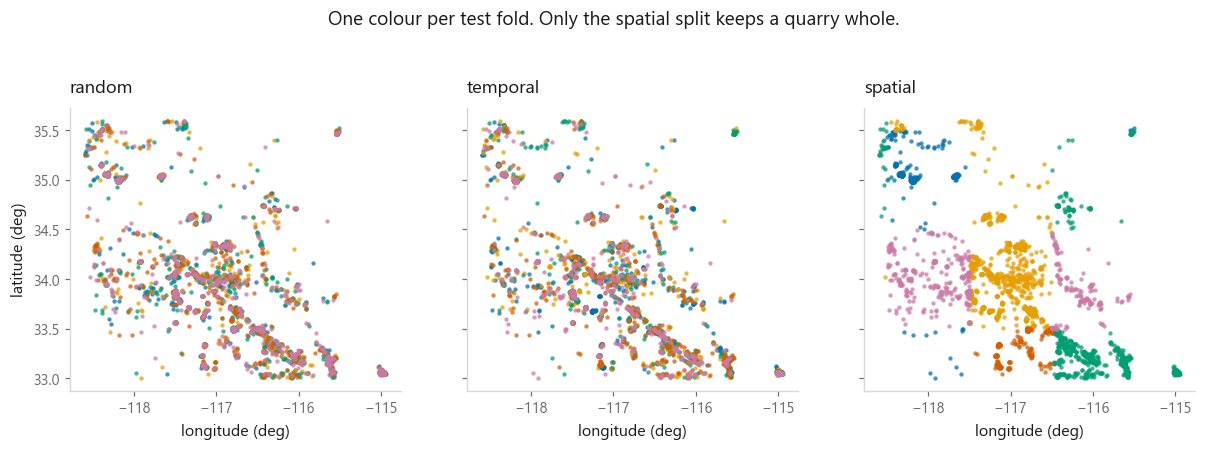

In [9]:
# Zoomed to the southern California quarry district. At national scale a quarry is
# a single pixel and all three schemes look identical; the question is whether one
# quarry's events end up in several folds, which is only visible close up.
LON_WINDOW, LAT_WINDOW = (-118.6, -114.8), (33.0, 35.6)
in_window = (events.longitude.between(*LON_WINDOW) & events.latitude.between(*LAT_WINDOW)).values

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.3), sharex=True, sharey=True)
fold_colours = [style.PALETTE[i] for i in range(5)]

for ax, (name, folds) in zip(axes, SPLITS.items()):
    for i, (_, test) in enumerate(folds):
        shown = test[in_window[test]]
        ax.scatter(events.longitude.values[shown], events.latitude.values[shown],
                   s=8, alpha=0.75, c=fold_colours[i], linewidths=0)
    ax.set_aspect(1 / np.cos(np.radians(34)))
    ax.grid(False)
    ax.set_xlabel("longitude (deg)")
    style.title(ax, name)

axes[0].set_ylabel("latitude (deg)")
fig.suptitle("One colour per test fold. Only the spatial split keeps a quarry whole.",
             x=0.5, y=1.00, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-splits.png")
print(f"showing {in_window.sum():,} events in the southern California window")

Colour is the fold each event was tested in, zoomed to the quarry district east
of Los Angeles. In the first two panels each quarry is a rosette of all five
colours, which means the quarry was in the training set every time it was tested.
In the third, a quarry is one colour: when it is tested, the model has never seen
it.

This picture is the reason a time split will not save me here. The leak is
geographic, and shuffling time does nothing to geography.

## The experiment

Three splits, four feature sets, three models, five folds each. Nothing is tuned:
I want to compare arrangements, and hyperparameter search would add a second
moving part.

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


def build_models():
    """Fresh, unfitted estimators. Called per fold so nothing carries over."""
    return {
        # Median imputation and scaling are needed by the linear model only; the
        # tree models are given the same imputation so all three see one dataset.
        "logistic regression": make_pipeline(
            SimpleImputer(strategy="median"), StandardScaler(),
            LogisticRegression(max_iter=2000)),
        "random forest": make_pipeline(
            SimpleImputer(strategy="median"),
            RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_SEED)),
        "gradient boosting": HistGradientBoostingClassifier(random_state=RANDOM_SEED),
    }


records = []
for split_name, folds in SPLITS.items():
    for set_name, columns in FEATURE_SETS.items():
        X = events[columns].values
        for model_name in build_models():
            for fold, (train, test) in enumerate(folds):
                model = build_models()[model_name].fit(X[train], y[train])
                probability = model.predict_proba(X[test])[:, 1]
                records.append({
                    "split": split_name, "features": set_name, "model": model_name,
                    "fold": fold,
                    "balanced_accuracy": balanced_accuracy_score(y[test], probability > 0.5),
                    "auc": roc_auc_score(y[test], probability),
                })
    print(f"finished {split_name}")

results = pd.DataFrame(records)
results.to_csv("results.csv", index=False)
print(f"\n{len(results)} model fits recorded")

finished random


finished temporal


finished spatial

180 model fits recorded


## The result

In [11]:
grid = (results.pivot_table(index=["features", "model"], columns="split",
                            values="balanced_accuracy")
        .reindex(["all", "where", "when", "how"], level=0)[["random", "temporal", "spatial"]])
print("balanced accuracy\n")
print(grid.round(3).to_string())

balanced accuracy

split                         random  temporal  spatial
features model                                         
all      gradient boosting     0.983     0.978    0.861
         logistic regression   0.870     0.866    0.816
         random forest         0.979     0.974    0.846
where    gradient boosting     0.977     0.972    0.736
         logistic regression   0.566     0.563    0.488
         random forest         0.987     0.983    0.700
when     gradient boosting     0.841     0.841    0.828
         logistic regression   0.833     0.833    0.824
         random forest         0.835     0.833    0.815
how      gradient boosting     0.886     0.865    0.739
         logistic regression   0.677     0.671    0.630
         random forest         0.887     0.865    0.746


gradient boosting : random 0.983  temporal 0.978  spatial 0.861
gap between the two tree models under a random split : 0.004
gap between random and spatial for gradient boosting  : 0.122
error rate: random 1.7% -> spatial 13.9% (8.1 times as many mistakes)


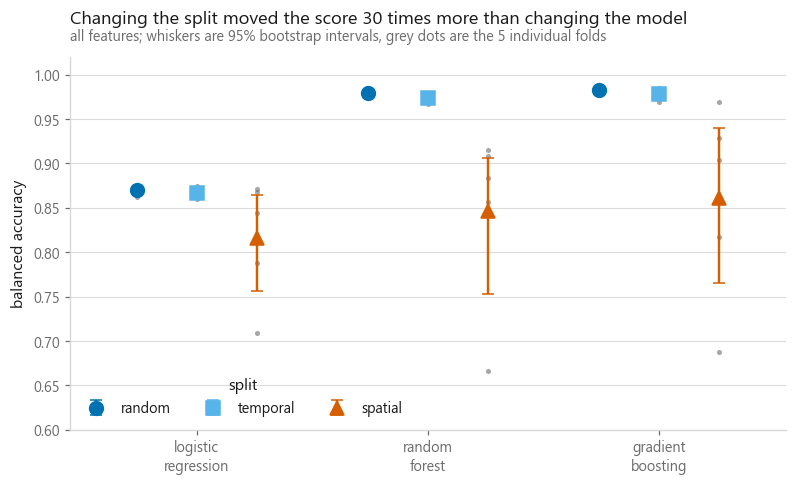

In [12]:
best = results[(results.features == "all")]
fig, ax = plt.subplots(figsize=(8.4, 4.4))

models = ["logistic regression", "random forest", "gradient boosting"]
split_order = ["random", "temporal", "spatial"]
split_colour = {"random": style.PALETTE[0], "temporal": style.PALETTE[5], "spatial": style.HIGHLIGHT}
width = 0.26

for j, split_name in enumerate(split_order):
    means, lows, highs = [], [], []
    for model_name in models:
        scores = best[(best.split == split_name) & (best.model == model_name)].balanced_accuracy
        mean, low, high = evaluate.bootstrap_ci(scores.values)
        means.append(mean); lows.append(mean - low); highs.append(high - mean)
    offset = (j - 1) * width
    # Points rather than bars. A bar chart carries an implicit zero, and this axis
    # does not start at zero, so bars here would exaggerate every difference.
    ax.errorbar(np.arange(3) + offset, means, yerr=[lows, highs], fmt=style.MARKERS[j],
                ms=9, color=split_colour[split_name], ecolor=split_colour[split_name],
                elinewidth=1.6, capsize=4, label=split_name, zorder=3, linestyle="none")
    for i, model_name in enumerate(models):
        scores = best[(best.split == split_name) & (best.model == model_name)].balanced_accuracy
        ax.scatter(np.full(len(scores), i + offset), scores, s=11,
                   c=style.MUTED, alpha=0.6, zorder=2, linewidths=0)

ax.set_xticks(range(3), [m.replace(" ", "\n") for m in models])
ax.set_xlim(-0.55, 2.55)
ax.set_ylim(0.6, 1.02)
ax.set_ylabel("balanced accuracy")
ax.legend(title="split", loc="lower left", ncols=3)
style.title(ax,
            "Changing the split moved the score 30 times more than changing the model",
            "all features; whiskers are 95% bootstrap intervals, grey dots are the 5 individual folds")
style.save(fig, FIG / "fig-05-result.png")

gb = best[best.model == "gradient boosting"].groupby("split").balanced_accuracy.mean()
rf = best[best.model == "random forest"].groupby("split").balanced_accuracy.mean()
print(f"gradient boosting : random {gb['random']:.3f}  temporal {gb['temporal']:.3f}  spatial {gb['spatial']:.3f}")
print(f"gap between the two tree models under a random split : {abs(gb['random'] - rf['random']):.3f}")
print(f"gap between random and spatial for gradient boosting  : {gb['random'] - gb['spatial']:.3f}")
print(f"error rate: random {1 - gb['random']:.1%} -> spatial {1 - gb['spatial']:.1%} "
      f"({(1 - gb['spatial']) / (1 - gb['random']):.1f} times as many mistakes)")

Reading that carefully, because the honest version is more interesting than the
slogan.

Among the two models anybody would actually pick between here, a random forest
and gradient boosting, the split changes the answer far more than the model does.
The two tree ensembles are within half a point of each other. Moving from a
random to a spatial split costs twelve.

Logistic regression is eleven points behind the trees, so if I include it, "the
split matters more than the model" stops being true as a blanket claim. It is
true among comparable models, which is the comparison practitioners are actually
making. I would rather say that precisely than have a cleaner headline.

The temporal split is the part worth pinning up. It costs half a point against
the random split, which is about what swapping the model costs. Someone who
reached for a time-based fold here, believing they had dealt with leakage, would
have bought almost nothing.

## Which signal survives

The score dropping is not the finding. The finding is what it drops *to*, and
which part of the model was holding it up.

split     random  temporal  spatial   drop
features                                  
where      0.977     0.972    0.736  0.241
how        0.886     0.865    0.739  0.148
all        0.983     0.978    0.861  0.122
when       0.841     0.841    0.828  0.014


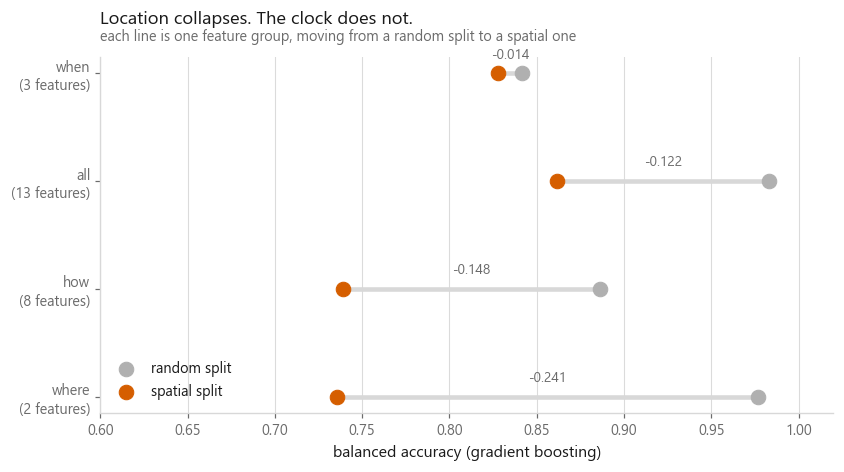

In [13]:
focus = results[results.model == "gradient boosting"]
order = ["where", "how", "all", "when"]

fig, ax = plt.subplots(figsize=(8.6, 4.2))
for i, set_name in enumerate(order):
    r = focus[(focus.features == set_name) & (focus.split == "random")].balanced_accuracy.mean()
    s = focus[(focus.features == set_name) & (focus.split == "spatial")].balanced_accuracy.mean()
    ax.plot([r, s], [i, i], color=style.RULE, lw=3, solid_capstyle="round", zorder=1)
    ax.scatter([r], [i], s=90, c=style.NEUTRAL, zorder=2, label="random split" if i == 0 else None)
    ax.scatter([s], [i], s=90, c=style.HIGHLIGHT, zorder=2, label="spatial split" if i == 0 else None)
    ax.annotate(f"{s - r:+.3f}", xy=((r + s) / 2, i), xytext=(0, 10),
                textcoords="offset points", ha="center", fontsize=9, color=style.MUTED)

ax.set_yticks(range(len(order)), [f"{s}\n({len(FEATURE_SETS[s])} features)" for s in order])
ax.set_xlim(0.6, 1.02)
ax.set_xlabel("balanced accuracy (gradient boosting)")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.legend(loc="lower left")
style.title(ax,
            "Location collapses. The clock does not.",
            "each line is one feature group, moving from a random split to a spatial one")
style.save(fig, FIG / "fig-06-reversal.png")

table = focus.pivot_table(index="features", columns="split", values="balanced_accuracy")
table["drop"] = table["random"] - table["spatial"]
print(table.reindex(order)[["random", "temporal", "spatial", "drop"]].round(3).to_string())

Under a random split, `where` beats `when` by a wide margin, and a reasonable
person reading that table would conclude that location is the informative
feature and the clock is a minor extra.

Under a spatial split the ordering reverses. Location falls by roughly a quarter
of its range and ends up the weakest group; the clock loses about a point and
becomes the strongest. The two conclusions are drawn from the same data and the
same model, and they disagree about what the model knows.

`how` sits in between, and its drop confirms the caveat I raised earlier: azimuthal
gap, station counts and distance-to-nearest-station describe the seismic network
around the event, and network geometry is a property of place. Those columns were
carrying location information under a physical-sounding name.

## How big should a block be?

One degree was a choice, and a result that depends on an arbitrary knob is not
much of a result. Sweeping it shows whether the effect is a real gradient or an
artefact of the number I picked.

        balanced_accuracy           auc       
                     mean    std   mean    std
degrees                                       
0.05                0.965  0.005  0.995  0.001
0.10                0.941  0.024  0.991  0.005
0.25                0.869  0.042  0.978  0.009
0.50                0.869  0.067  0.978  0.012
1.00                0.861  0.112  0.968  0.024
2.00                0.823  0.094  0.963  0.019
4.00                0.772  0.149  0.966  0.013

blocks per setting:
degrees
0.05    5525
0.10    3560
0.25    1674
0.50     801
1.00     364
2.00     165
4.00      62


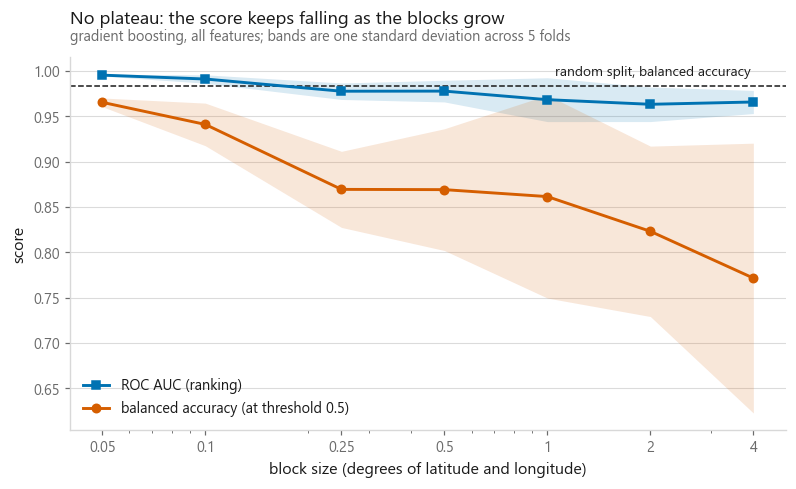

In [14]:
X_all = events[FEATURE_SETS["all"]].values
sweep = []
for degrees in [0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0]:
    grouping = ((events.latitude / degrees).round().astype(int).astype(str) + "_" +
                (events.longitude / degrees).round().astype(int).astype(str))
    for fold, (train, test) in enumerate(GroupKFold(5).split(X_all, y, groups=grouping)):
        model = HistGradientBoostingClassifier(random_state=RANDOM_SEED).fit(X_all[train], y[train])
        probability = model.predict_proba(X_all[test])[:, 1]
        sweep.append({
            "degrees": degrees, "blocks": grouping.nunique(), "fold": fold,
            "balanced_accuracy": balanced_accuracy_score(y[test], probability > 0.5),
            "auc": roc_auc_score(y[test], probability),
        })
sweep = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(8.4, 4.4))
for metric, colour, marker, label in [("auc", style.PALETTE[0], style.MARKERS[1], "ROC AUC (ranking)"),
                                      ("balanced_accuracy", style.HIGHLIGHT, style.MARKERS[0],
                                       "balanced accuracy (at threshold 0.5)")]:
    summary = sweep.groupby("degrees")[metric].agg(["mean", "std"])
    ax.plot(summary.index, summary["mean"], marker=marker, color=colour, label=label, zorder=3)
    ax.fill_between(summary.index, summary["mean"] - summary["std"], summary["mean"] + summary["std"],
                    color=colour, alpha=0.15, linewidth=0)

ax.axhline(gb["random"], color=style.INK, lw=1, ls="--")
ax.annotate("random split, balanced accuracy", xy=(4, gb["random"]), xytext=(-2, 7),
            textcoords="offset points", ha="right", fontsize=9, color=style.INK)
ax.set_xscale("log")
ax.set_xticks([0.05, 0.1, 0.25, 0.5, 1, 2, 4], ["0.05", "0.1", "0.25", "0.5", "1", "2", "4"])
ax.set_xlabel("block size (degrees of latitude and longitude)")
ax.set_ylabel("score")
ax.legend(loc="lower left")
style.title(ax,
            "No plateau: the score keeps falling as the blocks grow",
            "gradient boosting, all features; bands are one standard deviation across 5 folds")
style.save(fig, FIG / "fig-07-blocksize.png")

print(sweep.groupby("degrees")[["balanced_accuracy", "auc"]].agg(["mean", "std"]).round(3).to_string())
print("\nblocks per setting:")
print(sweep.groupby("degrees").blocks.first().to_string())

I expected this curve to fall and then level off, on the reasoning that once the
held-out region is genuinely unfamiliar there is no leak left to remove. It does
not level off. Balanced accuracy slides from 0.97 at a twentieth of a degree to
0.77 at four degrees and is still falling at the right-hand edge.

That means I cannot cleanly separate the two things that grow together as blocks
get bigger. Larger blocks remove more leakage, and they also push the test region
further from anything in the training set, which is a harder problem rather than
a fairer measurement of the same one. Without a plateau I have no way to say
where one effect ends and the other begins, so **the honest reading is that
"the" spatially blocked score does not exist — it is a function of a block size
I chose**. One degree is defensible because it is roughly the scale over which
quarry districts repeat, but it is a judgement, and I am reporting a number that
depends on it.

The two curves separating is the useful part. AUC, which only cares about
ranking, degrades gently. Balanced accuracy at a fixed threshold of 0.5 falls
much faster, and its fold-to-fold spread grows from 0.005 to 0.149. The model's
ability to *order* events by how explosion-like they are survives being moved to
a new region far better than its ability to place a decision boundary there. If
I deployed this, I would recalibrate the threshold per region and quote AUC.

The widening band at four degrees also deserves a caveat of its own: there are
only 62 blocks left, so the five folds become large and very unlike each other,
and the mean of five such folds is not a precise estimate of anything.

## Verdict

**Yes, the catalogue row is enough.** A gradient boosting model with no access to
any waveform separates catalogued explosions from earthquakes at a balanced
accuracy in the mid eighties even when it is forced to predict in regions it has
never seen. That is a genuinely useful result for triaging a catalogue, and it
costs nothing to compute.

**The split decided the number more than the model did.** Swapping a random
forest for gradient boosting moved the score by four tenths of a point. Swapping
a random split for a spatial one moved it by twelve, and multiplied the error
rate by eight. Among models a practitioner would actually be choosing between,
the arrangement of the folds was the larger decision.

**A temporal split bought almost nothing here.** It is the reflex answer to
leakage and it cost half a point — about what changing the model cost — because
the leak in this dataset is geographic and shuffling time leaves the map
untouched. The kind of blocking has to match the kind of dependence.

**The model was leaning on a map, and the clock is what held it up.** Location
alone scored 0.98 under a random split and fell to 0.74 under a spatial one.
Time of day alone scored 0.84 and barely moved. Under one split, location looks
like the important feature; under the other, it looks like the weakest. Same data,
same model.

### What this does not show

The labels are analyst decisions, not ground truth. If analysts label events near
known quarries as blasts partly *because* they are near known quarries, then some
of what I am calling a spatial leak is baked into the labelling, and no split can
remove it. Testing that would need events labelled from waveforms alone.

The spatially blocked number is not a single number. It depends on the block
size, and the block-size sweep never plateaued, so I cannot separate leakage
removed from difficulty added. Anyone quoting "the" spatial score, mine included,
is quoting a choice as if it were a measurement.

The result is one country and one decade. Networks with different station
densities and different labelling conventions could behave differently, and the
`how` group in particular is a function of network geometry that varies far more
between countries than within one.

I did not tune anything. A tuned model would score higher everywhere, and I have
no evidence about whether tuning would widen or narrow the gap between splits —
though I would expect it to widen it, since tuning on randomly split folds
optimises for the leak.

I also looked at permutation importance under both splits, expecting the feature
ranking to invert as cleanly as the group experiment did. It did not: latitude
stays near the top under spatial blocking, because latitude carries real coarse
signal as well as the quarry lookup. That chart is not in this notebook, because
it was ambiguous and an ambiguous figure argues for whatever the reader already
thought.

---

Data: U.S. Geological Survey, Earthquake Hazards Program, ANSS Comprehensive
Catalog, retrieved through the FDSN event service. Public domain.

Prior work and how this project differs: [`ORIGINALITY.md`](../../ORIGINALITY.md).

Elyes Lounissi ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)